# Value at Risk (VaR) calculation using Monte Carlo simulation

## Executive Summary
This notebook estimates 1-week Value at Risk (VaR) and Expected Shortfall (ES) for a diversified multi-asset portfolio and compares several risk-modeling approaches.

The analysis proceeds from historical and parametric benchmarks to Monte Carlo simulation under time-varying volatility. In particular, I evaluate geometric Brownian motion with historical volatility, CCC-GARCH(1,1) with Gaussian innovations, CCC-GARCH(1,1) with Student-t innovations, and CCC-GARCH(1,1) with skewed-t innovations.

VaR and ES are reported at the 97.5% confidence level. Model adequacy is assessed through distribution diagnostics, heteroskedasticity testing, convergence analysis, and backtesting. The purpose of the notebook is therefore twofold: to estimate portfolio tail risk and to justify model selection using statistical evidence rather than convenience.

## Table of content
1. Imports
2. Load data
3. Historical VaR calculation
4. Parametric VaR calculation
    1. Normality check
    2. Data smoothing with Exponentially Weighted Moving Average (EWMA)
5. Monte Carlo simulations
    1. Historical volatility
    2. CCC-GARCH(1,1) with gaussian innovation
    3. CCC-GARCH(1,1) with student-t innovation
    4. CCC-GARCH(1,1) with skewed-t innovation
6. Stress test of the correlation matrix and volatility
7. Conclusion

# 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scp
import scipy.optimize as op
from scipy.ndimage import median_filter
import pandas as pan
import glob as gb
import torch as tr
import time as ti
import sklearn as sk
import json
from Source.Plot import *
from Source.Utils import *
from Source.StatTest import *
from Source.MonteCarlo import *
from Source.Decorators import *
from Source.Mlp import *

# 2. Load Data
Load all data present in folder Data

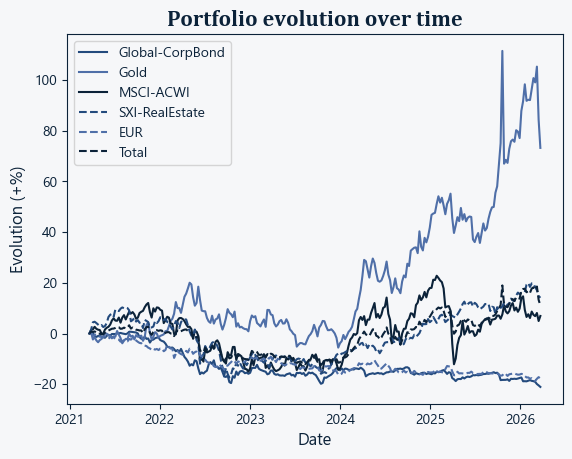

In [2]:
# Load data
(dataClose, dataDiv,dataCur, info)=loadAll()
#Show data evolution
plotPriceEvolution(dataClose,"Portfolio evolution over time")

### Interpretation
- The portfolio contains assets with different trends
- It covers both period of calm and crisis
- Different level of volatility are also present

# 3. Historical VaR calculation
- Return in percentage were calculated as it provide an intuitive way to look at the numbers

### Assumptions
- The past is representive of the future
- Returns are independent and identically distributed
- The chosen historical window is appropriate
- No structural breaks or regime change

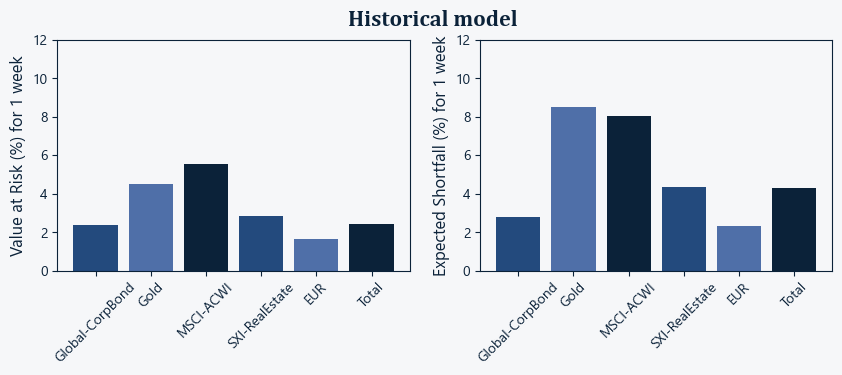

In [3]:
#Calculate returns
histVar=returnsP(dataClose)
#Historical VaR and ES
var_95=histVar.quantile(0.025)
es=[-histVar.iloc[:,i][histVar.iloc[:,i]<var_95.iloc[i]].mean() for i in range(len(var_95))]
#Plot
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:6]
plotBar(-var_95,es,colors,(0,12),dataClose.columns,"Value at Risk (%) for 1 week","Expected Shortfall (%) for 1 week","Historical model")

### Interpretations
- Gold and global equity show the highest risk
    - For gold, this is expected because of the rally that happened because of recent geopolic tensions
    - Same for global equity as logistic chain are perturbed and tariffs created uncertainties across the globe
- But overall ES indicate relatively low risk at short term
- Because the historical window mixes multiple market regimes, the resulting VaR estimate may understate short-horizon risk if recent volatility is materially above its long-run average.

The Gaussian specification is inadequate for this dataset, as it fails to capture the observed skewness, excess kurtosis, and volatility clustering. A heavier-tailed and heteroskedastic specification is therefore required.

# 4. Parametric model
- Model return with a parametric distribution
- Geometric brownian motion to model price movement
- Gaussian distribution is usually used

### Assumptions
- Return should follow a parametric distribution

## 4.1 Normality check
- Test if data are normally distributed
- Visually
- Statistical tests

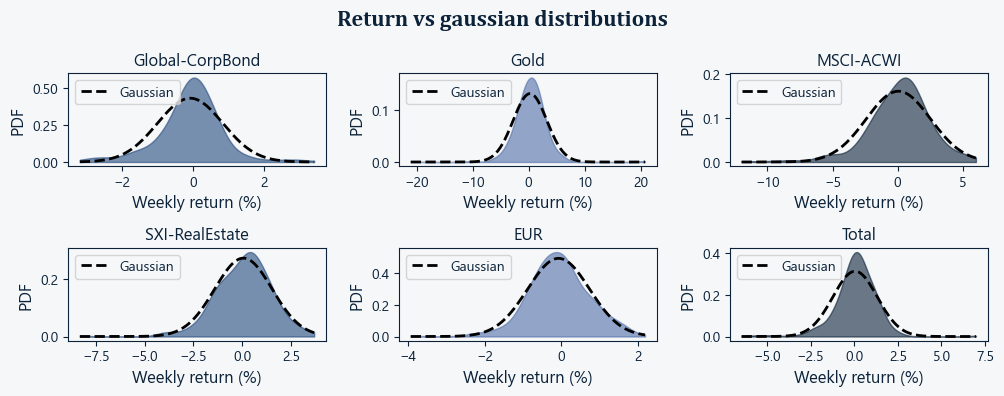

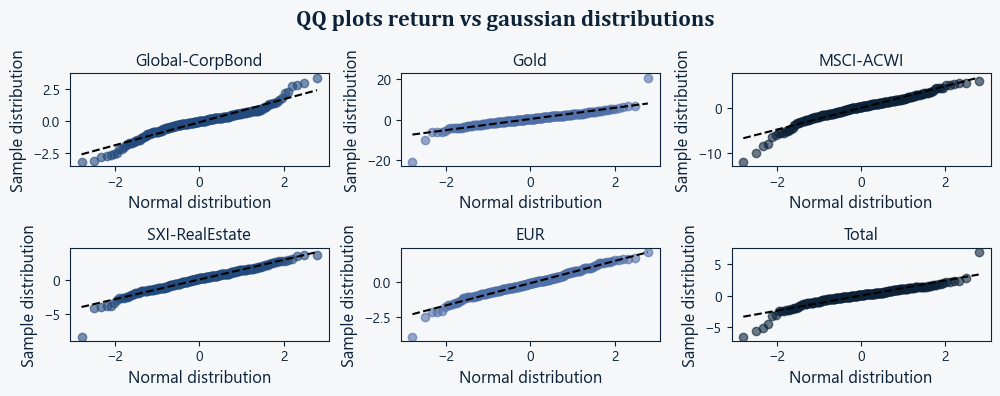

Normality test with 95% confidence level


,Anderson-Darling,Jarque-Bera
Global-CorpBond,Reject,Reject
Gold,Reject,Reject
MSCI-ACWI,Reject,Reject
SXI-RealEstate,Reject,Reject
EUR,Reject,Reject
Total,Reject,Reject


In [4]:
#Check if gaussian distribution is a good assumption for historical return distribution
checkDistribution(histVar,colors,"Return vs gaussian distributions")
checkDistributionQQ(histVar,colors,"QQ plots return vs gaussian distributions")
print("Normality test with 95% confidence level")
normalityTest(histVar)

### Interpretation
- Both test and plot indicate that the data are not normally distributed

Try to smooth data

## 4.2 Data smoothing with Exponentially Weighted Moving Average (EWMA)
- EWMA give more weight to recent data and smooth them

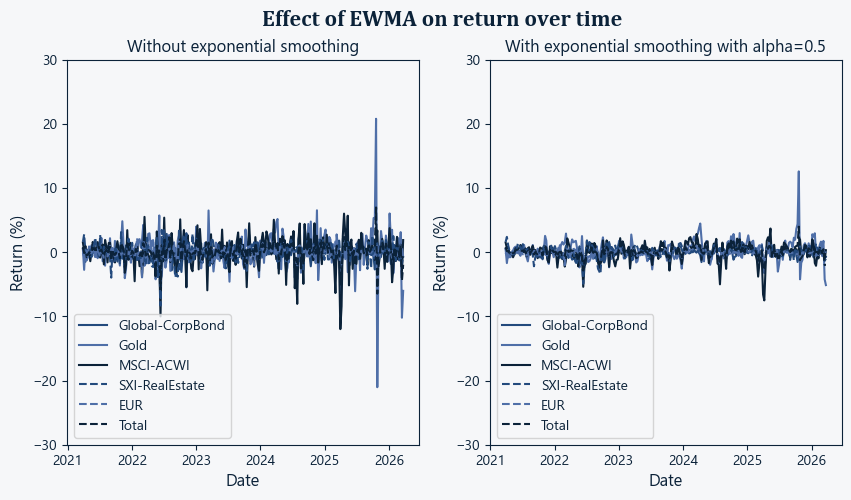

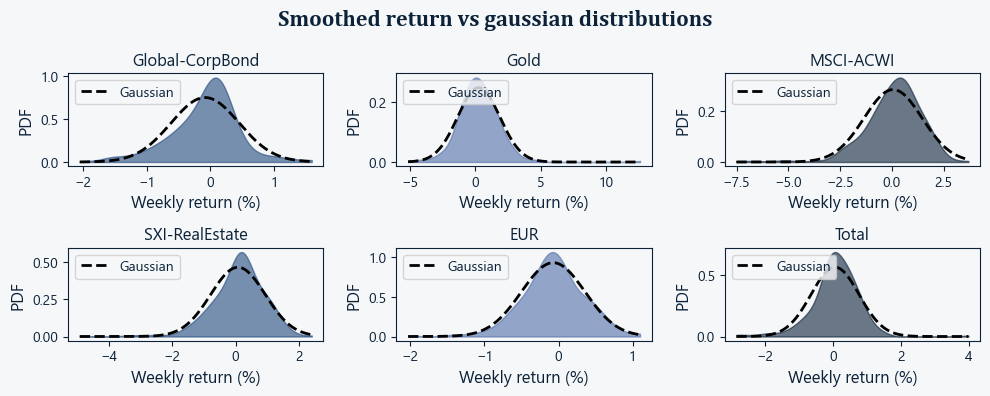

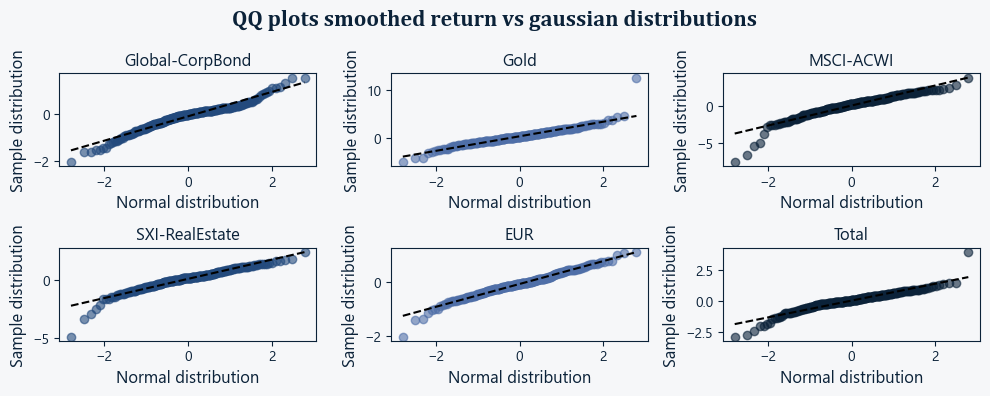

Normality test with 95% confidence level


,Anderson-Darling,Jarque-Bera
Global-CorpBond,Reject,Reject
Gold,Reject,Reject
MSCI-ACWI,Reject,Reject
SXI-RealEstate,Reject,Reject
EUR,Reject,Reject
Total,Reject,Reject


In [5]:
#Smoothing data with Exponential Moving Average
a=1-np.exp(-np.log(2)/1)#Smoothing factor equal to the half life of 1 week 
histVarSmooth=histVar.ewm(alpha=a).mean()
#Show comparison of return with and without smoothing
plotLineCompare(histVar,histVarSmooth,"Date","Return (%)","Without exponential smoothing","With exponential smoothing with alpha=0.5",(-30,30),"Effect of EWMA on return over time")
#Look at normality
checkDistribution(histVarSmooth,colors,"Smoothed return vs gaussian distributions")
checkDistributionQQ(histVarSmooth,colors,"QQ plots smoothed return vs gaussian distributions")
print("Normality test with 95% confidence level")
normalityTest(histVarSmooth)

### Interpretation
- Data are still not normally distributed according to test and visually

A more complex model must be used

# 5. Monte Carlo Simulation
- Simulate price movement at certain step using
- Different volatility model possible

### Assumptions
- Model to general return is correct
- Dependence structure between asset is correctly captured
- Enough simulations to converge results

## 5.1 Historical volatility
- Use mean historical volatility in the simulation

### Assumptions
- Volatility should be constant over time

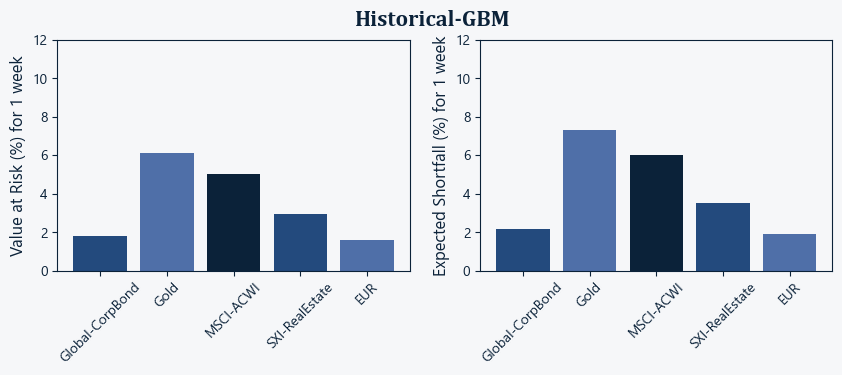

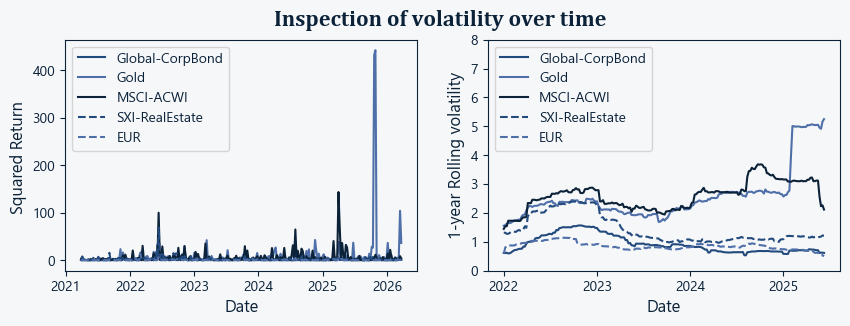

Homoscedasticity test with 95% confidence level


,Ljung-Box,Arch-LM
Global-CorpBond,Reject,Reject
Gold,Reject,Reject
MSCI-ACWI,Reject,Fail to reject
SXI-RealEstate,Reject,Reject
EUR,Reject,Reject


In [6]:
histVarP=histVar.iloc[:,:-1]
#Historical volatility
logHistVar=returnsL(dataClose.iloc[:,:-1])
volh=np.asarray(logHistVar.std())
sim=MCSim(np.array(dataClose.iloc[0,:-1]),volh,0,1,1,100000,0.025)
t1=sim.VaR(False)
plotBar(t1[0],t1[1],colors,(0,12),histVarP.columns,"Value at Risk (%) for 1 week","Expected Shortfall (%) for 1 week","Historical-GBM")
#Backtesting
k1=kupiec(histVarP,t1[0])
ku=pan.DataFrame([k1[0]],columns=histVarP.columns,index=["Historical"]).T
ku
#Check heteroskedasticity
checkVisualHeteroskedasticity(histVarP,"Inspection of volatility over time")
histVar2=histVarP**2
lb=[]
for name in histVar2.columns:
    lb.append([ljung_box_test(histVar2[name]),arch_lm_test(histVar2[name])])
print("Homoscedasticity test with 95% confidence level")
pan.DataFrame(lb,index=histVar2.columns,columns=["Ljung-Box","Arch-LM"])

### Interpretations
- Volatility is not constant over time, so the model is not adapted

Need a model to estimate volatility

## 5.2 CCC-GARCH(1,1) with gaussian innovation
- Model volatility with a generalized autoregressive conditional heteroscedasticity
- Gaussian innovation distribution is used for discrete-time shocks
- Shocks use the correlation matrix to propagate accordingly
- Use Engle-Sheppard to test constant correlation
- Use Kupiec test to backtest model against historical data for exception rate

### Assumptions
- Correlation between assets is constant over time
- Innovation is normally distributated

In [7]:
#GARCH
corrst2,var2,param2,srr2=correlMap(logHistVar)
print("Engle-Sheppard test for constant correlation at 95% Confidence level:")
engle_sheppard_test(srr2,corrst2)

Engle-Sheppard test for constant correlation at 95% Confidence level:


'Fail to reject'

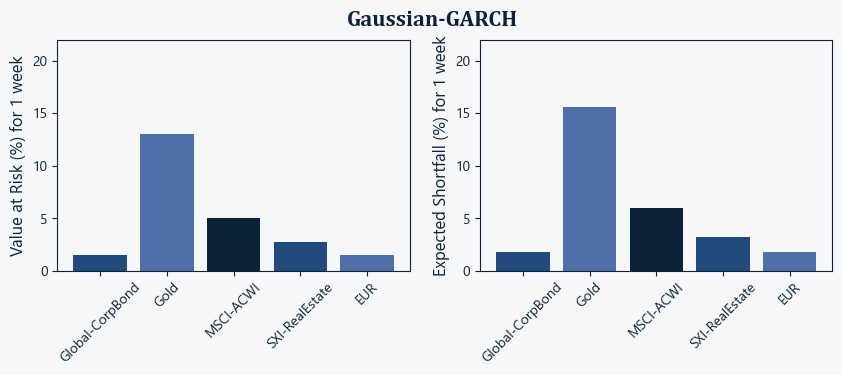

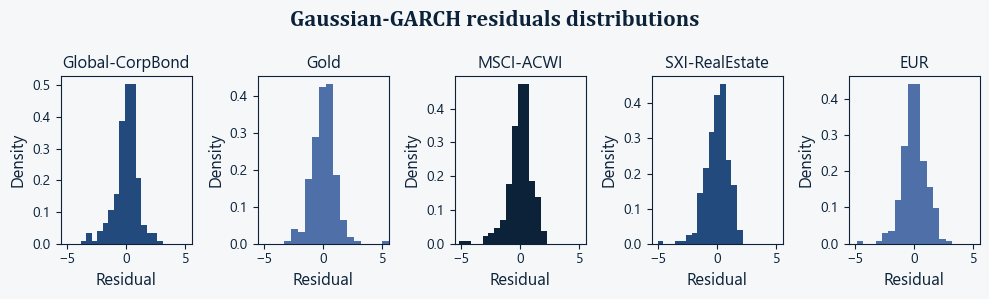

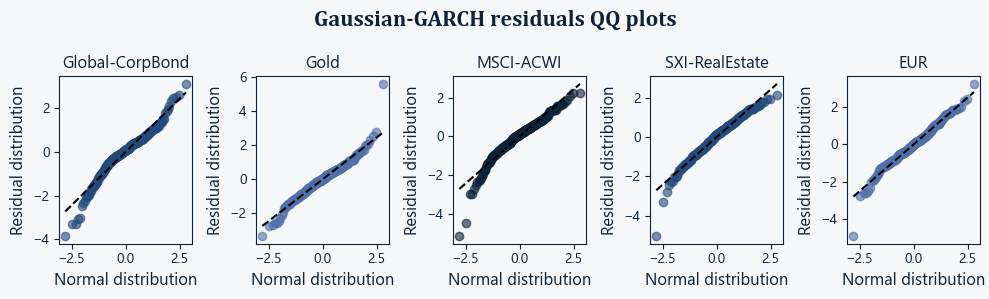

,Historical,Gaussian-GARCH
Global-CorpBond,Fail to Reject,Reject
Gold,Fail to Reject,Reject
MSCI-ACWI,Fail to Reject,Fail to Reject
SXI-RealEstate,Fail to Reject,Fail to Reject
EUR,Fail to Reject,Fail to Reject


In [8]:
#Calculate VaR and ES using GARCH
sim.set_garch(corrst2,param2,var2[:,-1],logHistVar.iloc[-2])
t2=sim.VaR(True)
plotBar(t2[0],t2[1],colors,(0,22),logHistVar.columns,"Value at Risk (%) for 1 week","Expected Shortfall (%) for 1 week","Gaussian-GARCH")
k2=kupiec(histVarP,t2[0])
ku["Gaussian-GARCH"]=k2[0]
plotResidual(srr2,colors,"Gaussian-GARCH residuals distributions",15)
checkDistributionQQ5(srr2,colors,"Gaussian-GARCH residuals QQ plots")
ku

### Interpretations
- Fail to reject with Engle-Sheppard test that the correlation is constant over time
- Reject Kupiec test for exception rate
- Residual distribution is also normally distributed indicating good fitting of the GARCH model

Constant correlation is good, but not the gaussian innovation distribution

## 5.3 CCC-GARCH(1,1) with student-t innovation
- Student-t innovation distribution is used for discrete-time shocks

### Assumptions
- Correlation between assets is constant over time
- Innovation is Student-t distributed

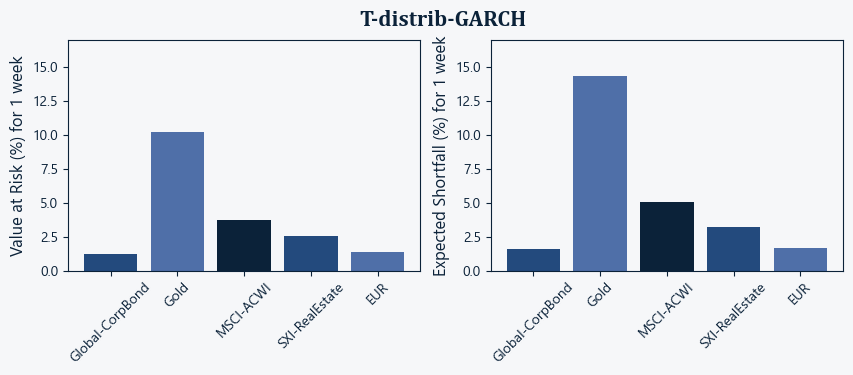

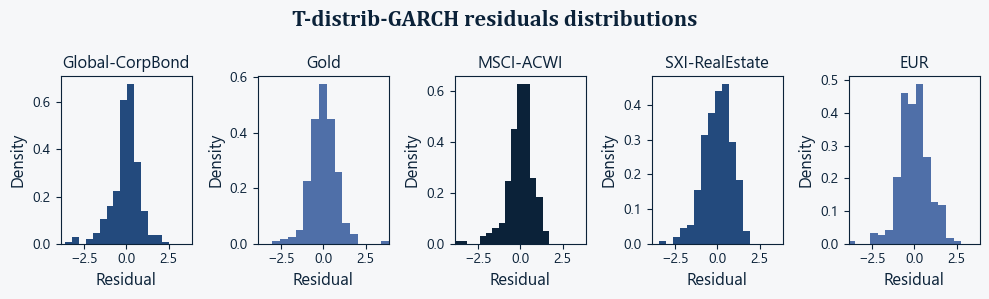

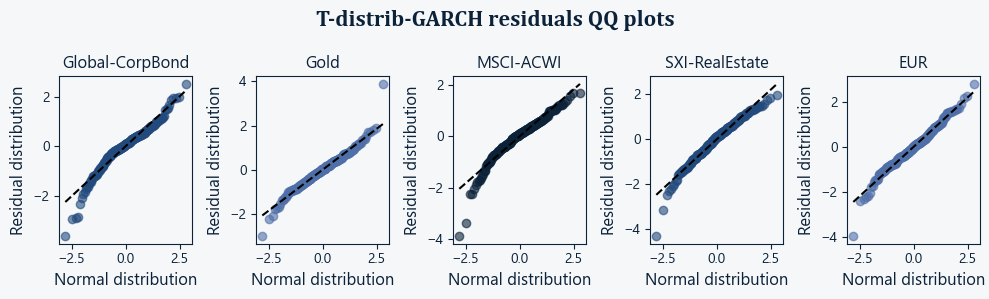

Engle-Sheppard test for constant correlation at 95% Confidence level:Fail to reject


,Historical,Gaussian-GARCH,T-distrib-GARCH
Global-CorpBond,Fail to Reject,Reject,Reject
Gold,Fail to Reject,Reject,Fail to Reject
MSCI-ACWI,Fail to Reject,Fail to Reject,Reject
SXI-RealEstate,Fail to Reject,Fail to Reject,Fail to Reject
EUR,Fail to Reject,Fail to Reject,Fail to Reject


In [9]:
corrst3,var3,param3,srr3=correlMap(logHistVar,"t")
#Calculate VaR and ES using GARCH with t distribution
sim.set_garch(corrst3,param3,var3[:,-1],logHistVar.iloc[-2],"t")
t3=sim.VaR(True)
plotBar(t3[0],t3[1],colors,(0,17),logHistVar.columns,"Value at Risk (%) for 1 week","Expected Shortfall (%) for 1 week","T-distrib-GARCH")
#Backtesting
k3=kupiec(histVarP,t3[0])
ku["T-distrib-GARCH"]=k3[0]
plotResidual(srr3,colors,"T-distrib-GARCH residuals distributions",15)
checkDistributionQQ5(srr3,colors,"T-distrib-GARCH residuals QQ plots")
print("Engle-Sheppard test for constant correlation at 95% Confidence level:"+engle_sheppard_test(srr3,corrst3))
ku

### Interpretations
- Kupiec test is rejected for several assets, indicating inappropriate exception level with confidence one
- Residual distribution is also normally distributed indicating good fitting of the GARCH model

## 5.4 CCC-GARCH(1,1) with skewed-t innovation
- Skewed-t innovation distribution is used for discrete-time shocks
- Used Hansen 1994 definition for the Skewed-t distribution
- Use Christoffersen test to check both exception and clustering of exceptions
- Look at cumulative exception over time for visual inspection

### Assumptions
- Correlation between assets is constant over time
- Innovation is Skewed-t distributated

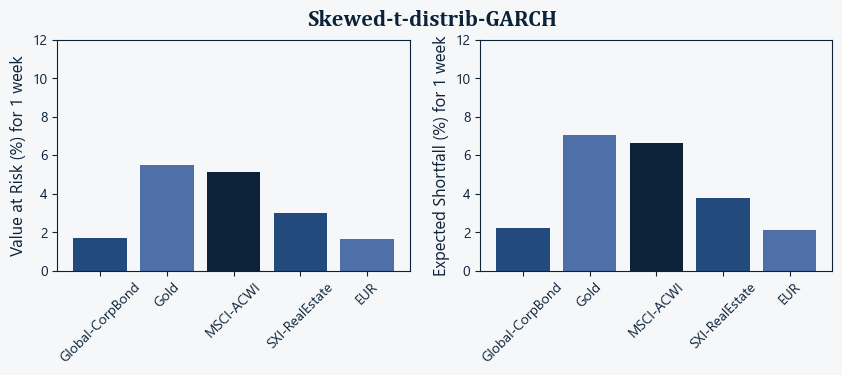

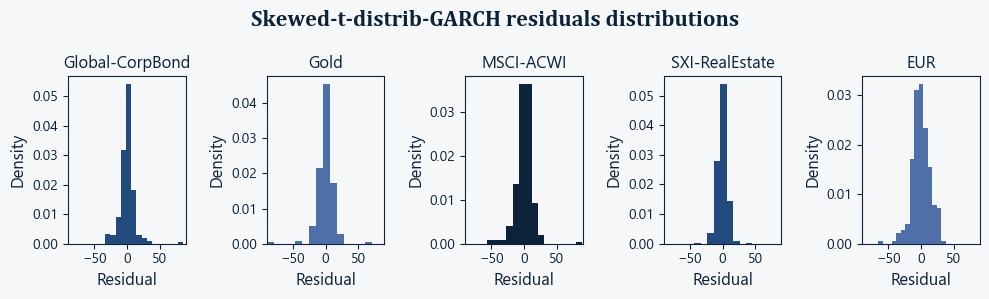

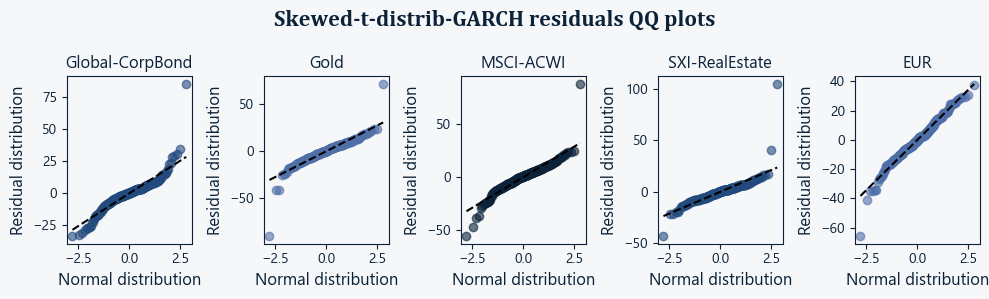

Engle-Sheppard test for constant correlation at 95% Confidence level:Fail to reject


,Historical,Gaussian-GARCH,T-distrib-GARCH,Skewed-t-distrib-GARCH
Global-CorpBond,Fail to Reject,Reject,Reject,Reject
Gold,Fail to Reject,Reject,Fail to Reject,Fail to Reject
MSCI-ACWI,Fail to Reject,Fail to Reject,Reject,Fail to Reject
SXI-RealEstate,Fail to Reject,Fail to Reject,Fail to Reject,Fail to Reject
EUR,Fail to Reject,Fail to Reject,Fail to Reject,Fail to Reject


In [10]:
#Skewed t-distribution GARCH
corrst4,var4,param4,srr4=correlMap(logHistVar,"skewed-t")
#Calculate VaR and ES using GARCH with t distribution
sim.set_garch(corrst4,param4,var4[:,-1],logHistVar.iloc[-2],"skewed-t")
t4=sim.VaR(True)
plotBar(t4[0],t4[1],colors,(0,12),logHistVar.columns,"Value at Risk (%) for 1 week","Expected Shortfall (%) for 1 week","Skewed-t-distrib-GARCH")
#Backtesting
k4=kupiec(histVarP,t4[0])
ku["Skewed-t-distrib-GARCH"]=k4[0]
plotResidual(srr4,colors,"Skewed-t-distrib-GARCH residuals distributions",15)
checkDistributionQQ5(srr4,colors,"Skewed-t-distrib-GARCH residuals QQ plots")
print("Engle-Sheppard test for constant correlation at 95% Confidence level:"+engle_sheppard_test(srr4,corrst4))
ku

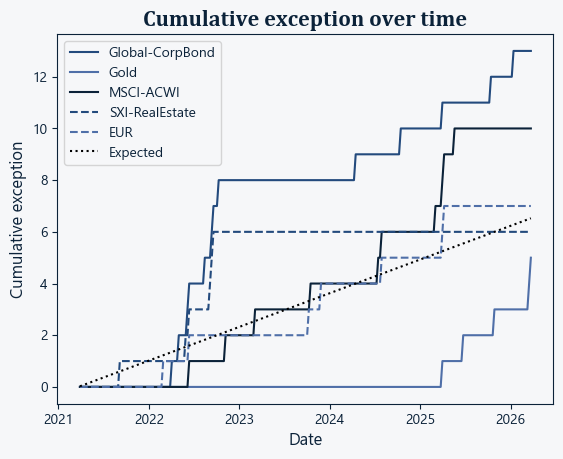

,Christoffersen test
Global-CorpBond,Fail to reject
Gold,Fail to reject
MSCI-ACWI,Fail to reject
SXI-RealEstate,Reject
EUR,Fail to reject


In [11]:
#Christoffersen and cumulative exception over time plot
ch=christoffersens(histVarP,t4[0])
plotCumulativeExcept(histVarP,t4[0])
pan.DataFrame(ch,columns=["Christoffersen test"],index=histVarP.columns)

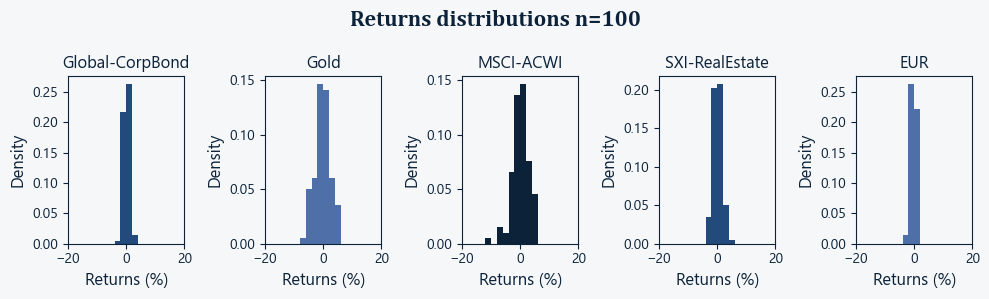

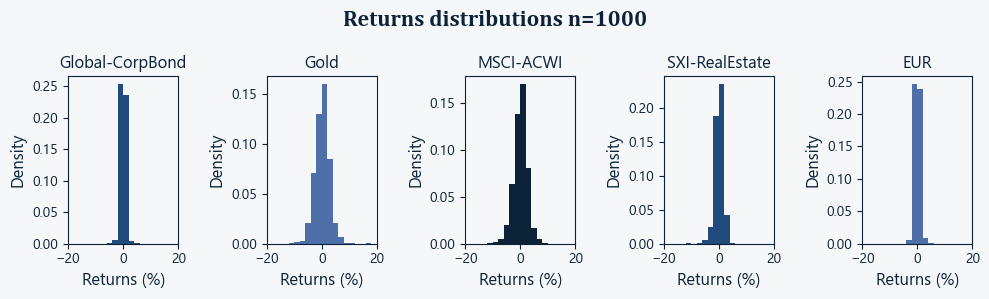

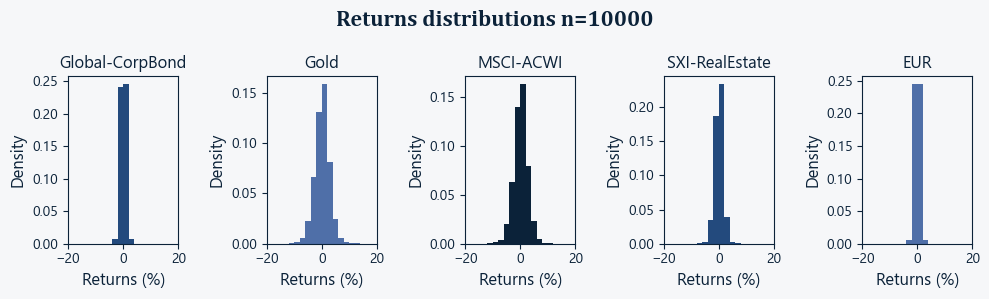

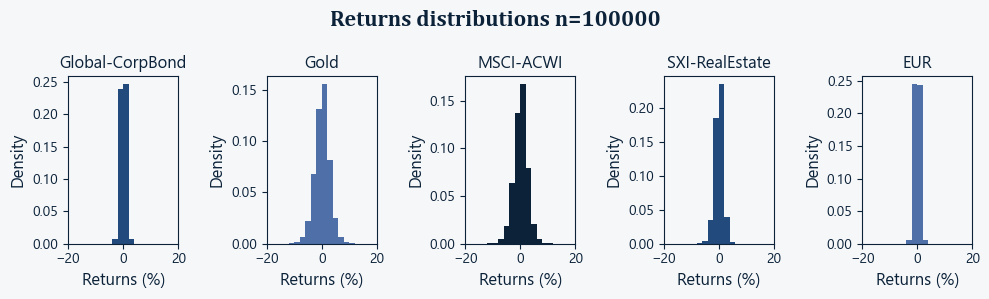

In [12]:
#Test convergence of simulation
sim.nbsim=100000
t100000=sim.simulate_paths_GARCH()
sim.nbsim=10000
t10000=sim.simulate_paths_GARCH()
sim.nbsim=1000
t1000=sim.simulate_paths_GARCH()
sim.nbsim=100
t100=sim.simulate_paths_GARCH()
#Calculate returns
r100=pan.DataFrame((t100[:,-1]-t100[:,-2])/t100[:,-2]*100,columns=logHistVar.columns)
r1000=pan.DataFrame((t1000[:,-1]-t1000[:,-2])/t1000[:,-2]*100,columns=logHistVar.columns)
r10000=pan.DataFrame((t10000[:,-1]-t10000[:,-2])/t10000[:,-2]*100,columns=logHistVar.columns)
r100000=pan.DataFrame((t100000[:,-1]-t100000[:,-2])/t100000[:,-2]*100,columns=logHistVar.columns)
#Plot
plotDistrib(r100,colors,"Returns distributions n=100",(-20,20),20)
plotDistrib(r1000,colors,"Returns distributions n=1000",(-20,20),20)
plotDistrib(r10000,colors,"Returns distributions n=10000",(-20,20),20)
plotDistrib(r100000,colors,"Returns distributions n=100000",(-20,20),20)

### Interpretations
- Kupiec test was not rejected for all assets, indicating appropriate exception level with confidence one
- Residual distribution is also normally distributed indicating good fitting of the GARCH model
- Fail to reject Christoffersen test, indicating that exception and distribution of exception over time is appropriate with the confidence level
- Plot of cummulative exception over time show relatively similar profile to expected one
- Due to the low number of expected exception, small deviation from the expected profile can have strong influence on the curves
- With n=100000 the convergence is achieved


Model is appropriate

# 6. Stress test of the correlation matrix and volatility
- Look at possible effect of correlation matrix and volatility model on VaE and ES
- Make stress correlation map with increase correlation between all assets
- Increase volatility with a scaling factor
- Test separate and combined effect

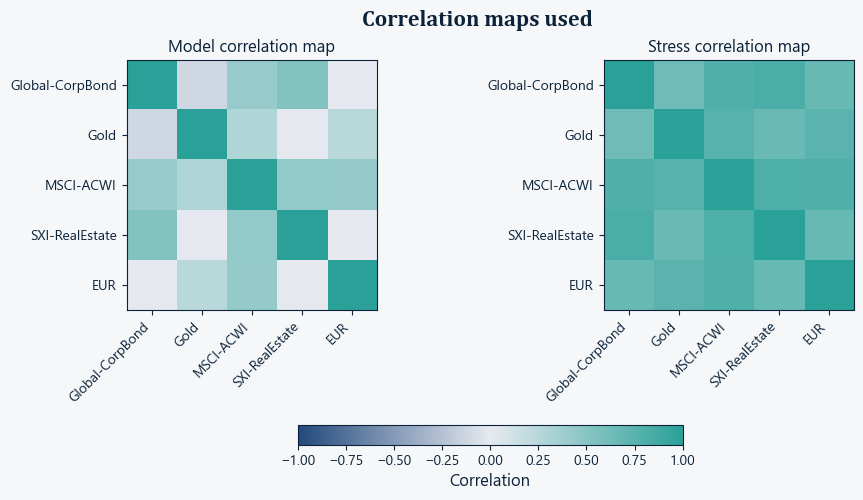

Stress multiplier (Stressed VaR/Baseline VaR)


,Global-CorpBond,Gold,MSCI-ACWI,SXI-RealEstate,EUR
Model,1.0,1.0,1.0,1.0,1.0
Correlation stress,0.9,1.0,1.1,1.0,0.9
Volatility stress,3.2,2.9,2.6,3.0,2.6
Volatility+Correlation stress,3.1,3.0,3.9,3.6,3.3


In [13]:
#Stress test correlation map
corrStress=corrst4.copy(deep=True)*10
corrStress=increase_corr(corrst4,0.7,0.95)
plotCompareCorrMap(corrst4,corrStress,logHistVar)
#Var with correlation stress
sim.set_garch(corrStress,param4,var4[:,-1],logHistVar.iloc[-2],"skewed-t")
tStressC=sim.VaR(True)
#Var with Volatility stress
sim.set_garch(corrst4,param4,var4[:,-1]*2,logHistVar.iloc[-2],"skewed-t")
sim.stress=2#Double volatility
tStressV=sim.VaR(True)
#Var with both volatility and correlation stress
sim.set_garch(corrStress,param4,var4[:,-1]*2,logHistVar.iloc[-2],"skewed-t")
tStressCV=sim.VaR(True)
print("Stress multiplier (Stressed VaR/Baseline VaR)")
summary=pan.DataFrame([t4[0],tStressC[0],tStressV[0],tStressCV[0]],columns=logHistVar.columns,index=["Model","Correlation stress","Volatility stress","Volatility+Correlation stress"])
summary2=summary/summary.iloc[0]
summary2.round(1)


In [14]:
print("Tail risk ratio (ES/VaR)")
summary3=pan.DataFrame([t4[1],tStressC[1],tStressV[1],tStressCV[1]],columns=logHistVar.columns,index=["Model","Correlation stress","Volatility stress","Volatility+Correlation stress"])
summary3/=summary
summary3.round(1)

Tail risk ratio (ES/VaR)


,Global-CorpBond,Gold,MSCI-ACWI,SXI-RealEstate,EUR
Model,1.3,1.3,1.3,1.3,1.3
Correlation stress,1.5,1.3,1.2,1.2,1.3
Volatility stress,1.4,1.7,1.2,1.1,1.1
Volatility+Correlation stress,1.3,1.2,1.2,1.2,1.3


### Interpretations
- Increase in correlation map increase VaR and ES, highlighting diversification of the portfolio
- Volatility has the strongest effect
- Since the current situation is already a crisis situation, the stress values might be too conservative

# 7. Conclusions
The analysis shows that simple Gaussian and constant-volatility assumptions are not adequate for this portfolio. Asset returns exhibit non-normality and volatility clustering, which materially affect tail-risk estimation.

Among the specifications tested, CCC-GARCH(1,1) with skewed-t innovations provides the most credible representation of portfolio risk over the sample. It captures time-varying volatility, allows for asymmetric and heavy-tailed shocks, and performs best under VaR backtesting diagnostics.

Two practical conclusions follow. First, model choice has a meaningful impact on reported VaR and ES, especially when recent market conditions differ from the long-run sample average. Second, for this portfolio, volatility shocks are a more important driver of tail risk than correlation stress, while the ES/VaR ratio remains broadly stable under the scenarios considered.

Overall, the project illustrates a full risk-modeling workflow: benchmark construction, distributional diagnostics, volatility modeling, Monte Carlo scenario generation, backtesting, convergence analysis, and stress testing.


# 8. Stress detection

In [188]:
# Load data
(dataClose, dataDiv,dataCur, info)=loadAll()
#Show data evolution
histVar=returnsS(dataClose)
histVar=histVar.iloc[:,:-1]
logHistVar=returnsL(dataClose)

In [206]:
loss_fn=vae_loss
batch_size=[16,32,64]
h=[4,6,8,12,26]
si=len(histVar.columns)
ms=[1.1,1.5,2,3]
ls=[1,2,3,4,5,6,7,8]
fe=6
layer=gen_mode([fe*si],ms,ls)
learning_rate=(-4,-1)
dropout=(0.1,0.4)

In [207]:
opti=random_opti(histVar,5000,batch_size,layer,h,learning_rate,dropout,loss_fn,0.8,0.9,500,10,5,0.05,10,si,fe)

Epoch: 1/500
Model remaining: 5000/5000
Time: 1.7m

Epoch: 11/500
Model remaining: 710/5000
Best: 4.66e+04
Mean improvement: 2.0%
Time: 8.3m

Epoch: 21/500
Model remaining: 58/5000
Best: 4.65e+04

All models converged or got killed

Calculating R2


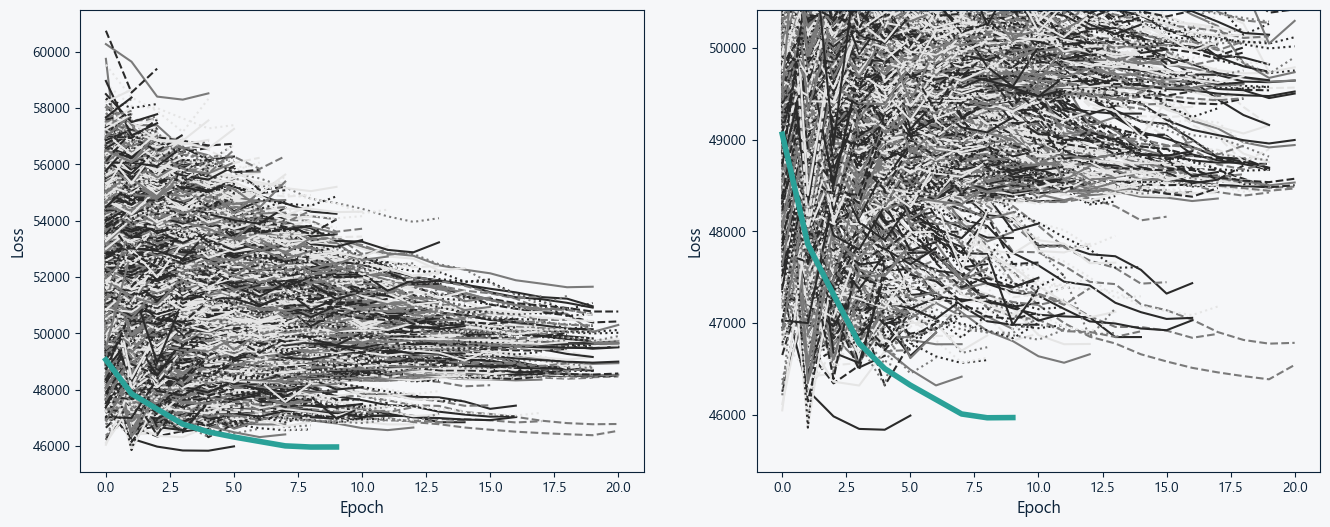

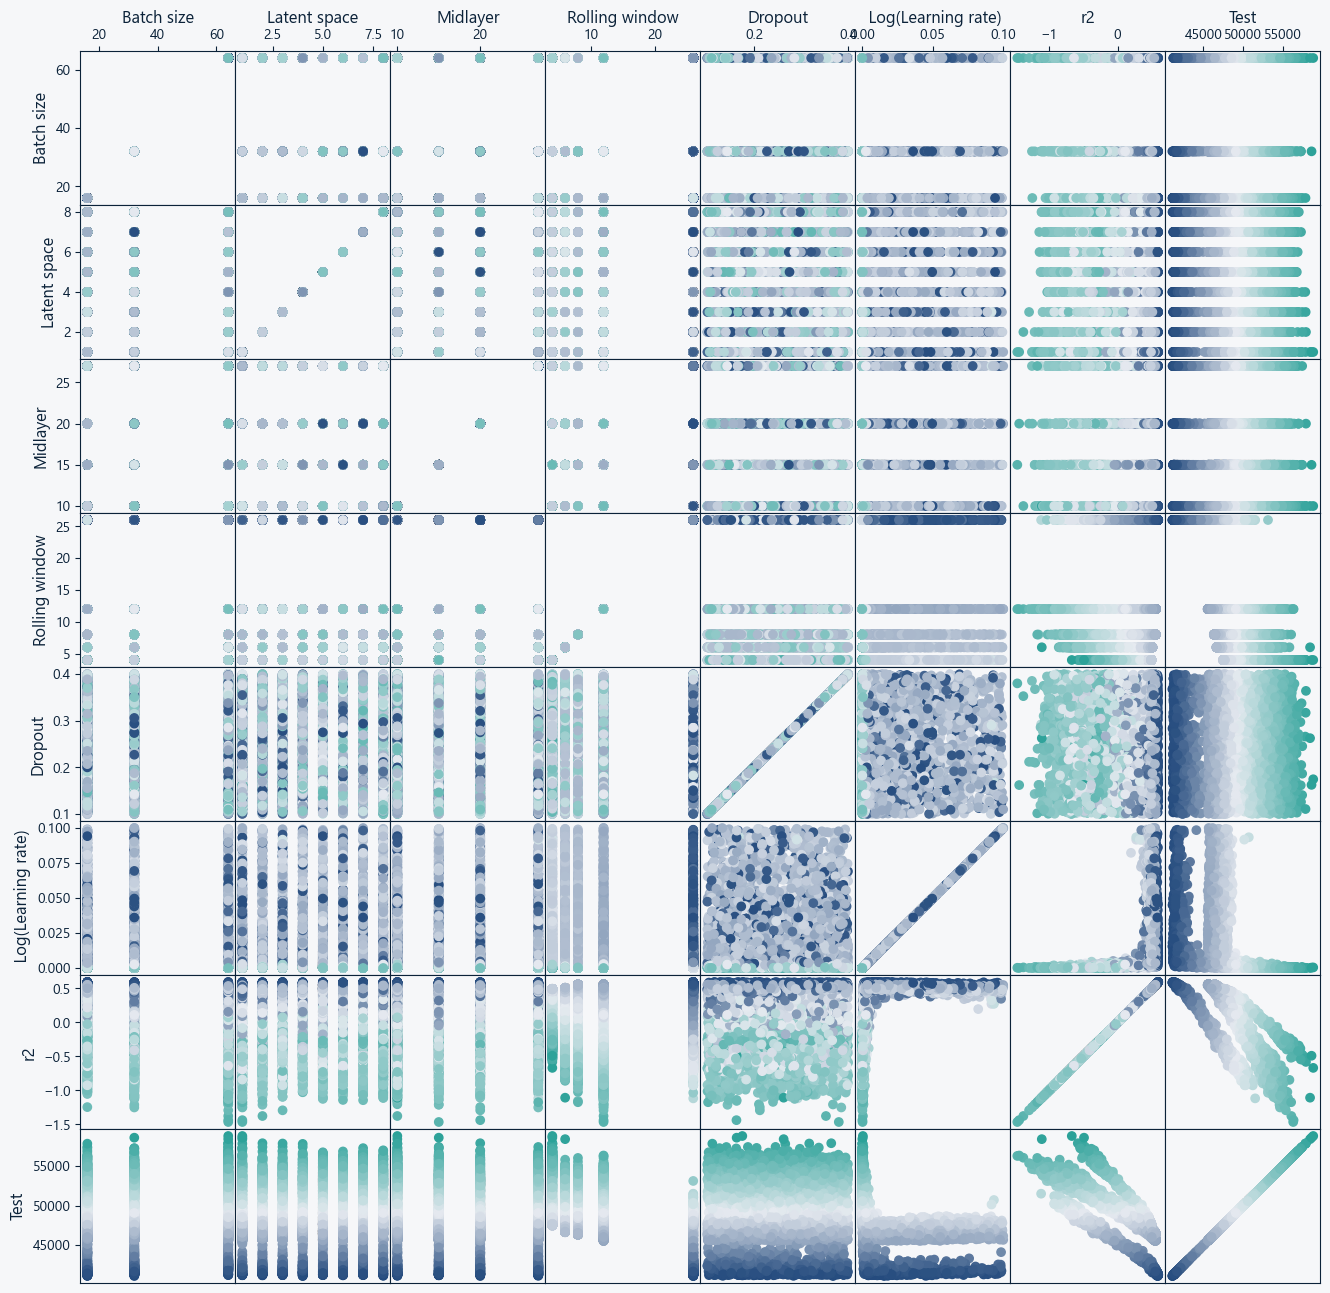

In [255]:
plotNNProgess(opti,0.1)
name=["Batch size","Latent space","Midlayer","Rolling window","Dropout"," Log(Learning rate)","r2","Test"]
plotParamNN(name,opti)

In [210]:
popti=opti["Model"]
wopti=opti["Weights"]
progress=opti["Valid"][:,:,1].copy()
progress[progress==0]=np.nan
top=np.zeros(progress.shape[1])
for i in range(len(top)):
    tmp=progress[~np.isnan(progress[:,i]),i]
    top[i]=tmp[-1]
best=np.argmin(top)
popti=popti[best]
wopti=wopti[best]
tr.torch.save(wopti,"Results/weights.pth")
popti={"Window":int(popti[0]),"BatchSize":int(popti[1]),"Dimensions":[int(x) for x in popti[2]]}
with open("Results/model.json","w") as f:
    json.dump(popti,f,indent=4)

In [211]:
with open("Results/model.json","r") as f:
    popti=json.load(f)
wopti=tr.torch.load("Results/weights.pth")
mopti=VariationalAutoencoder(popti["Dimensions"],0).to("cpu")
mopti.load_state_dict(wopti)

<All keys matched successfully>

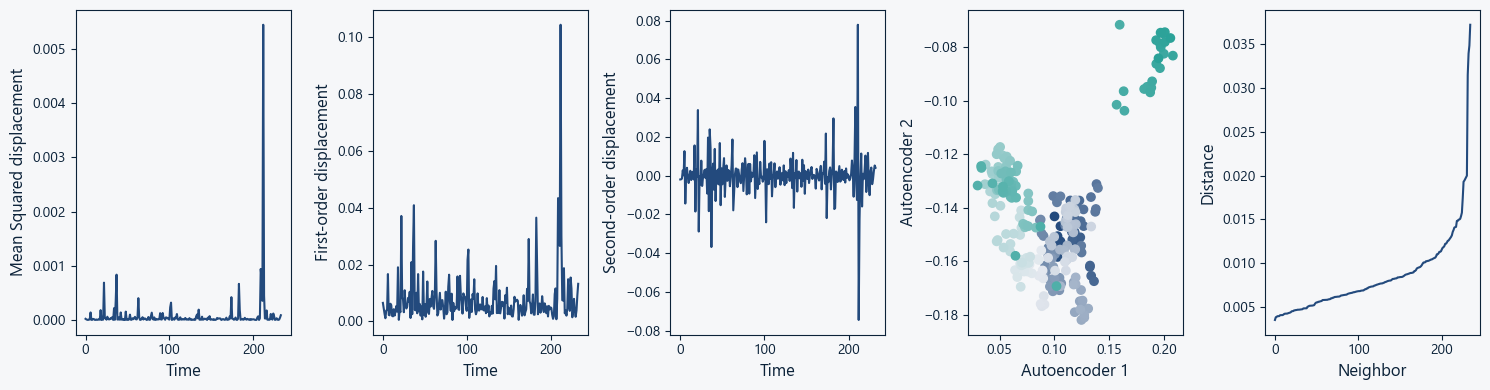

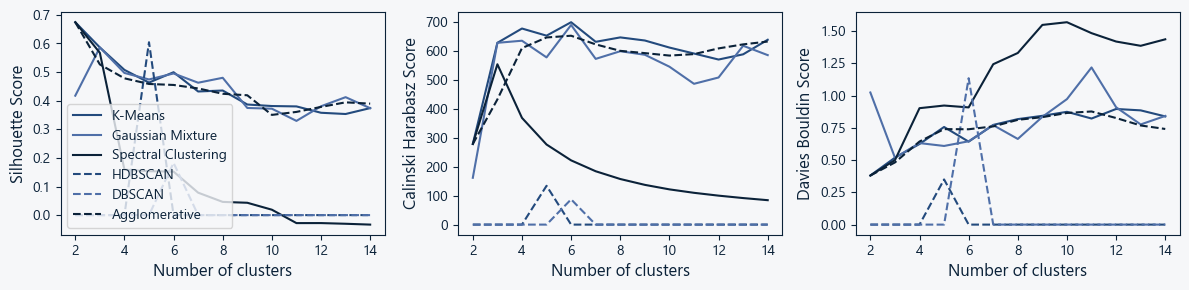

In [238]:
data=TickData(histVar,popti["Window"])
data_loader=tr.utils.data.DataLoader(data)
mopti.eval()
coded=np.zeros((len(data),popti["Dimensions"][-1]*2))
with tr.torch.no_grad():
    for id,(x,y) in enumerate(data_loader):
        tmp=mopti.encode(x)
        coded[id]=[tmp[0].numpy()[0][0],tmp[1].numpy()[0][0]]
msd,vel,acc=plotLatent(coded,10)
r=np.arange(2,15)
plotClusterScores(r,coded,0.01,10)

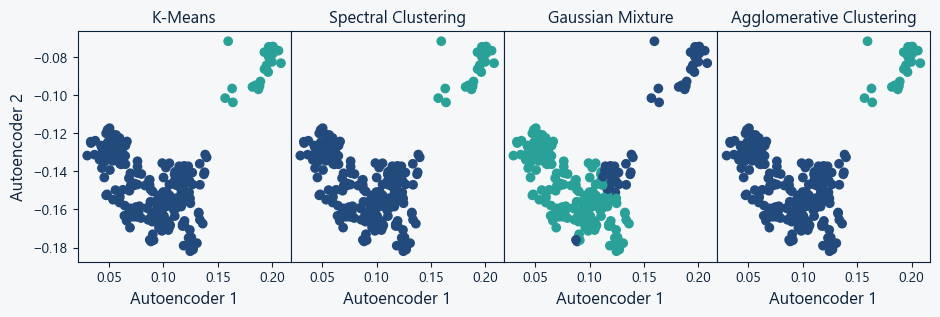

In [242]:
nbc=2
toda=coded
labels=sk.cluster.KMeans(n_clusters=nbc,random_state=0).fit_predict(toda)
labels2=sk.cluster.SpectralClustering(n_clusters=nbc,random_state=0).fit_predict(toda)
labels3=sk.mixture.GaussianMixture(n_components=nbc).fit_predict(toda)
labels4=sk.cluster.AgglomerativeClustering(n_clusters=nbc).fit_predict(toda)
la=[labels,labels2,labels3,labels4]
title=["K-Means","Spectral Clustering","Gaussian Mixture","Agglomerative Clustering"]
plotClusterDim(la,toda,title)

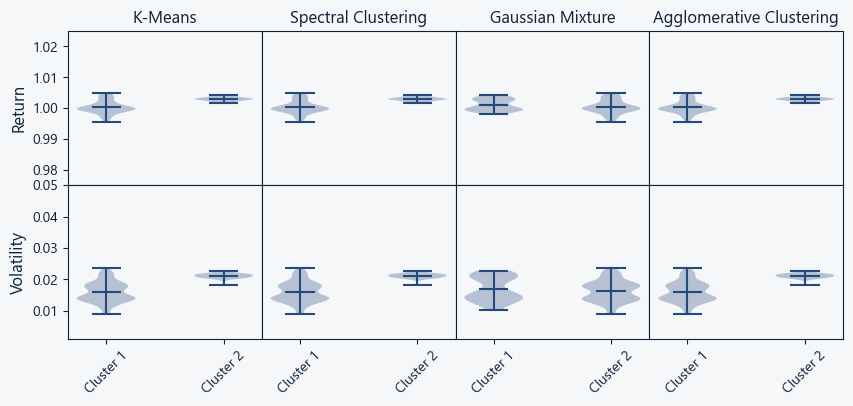

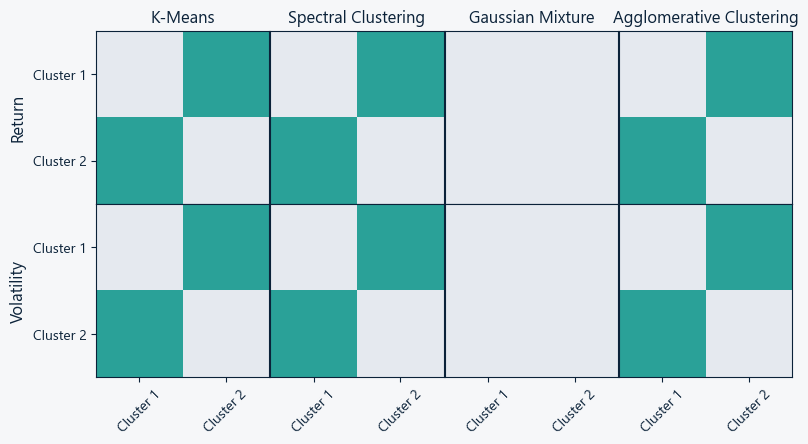

In [270]:
plotClusterMean(histVar,la,title,popti["Window"],(0.975,1.025),(0.001,0.05))